In [4]:
EXPERIMENT_IDS=["588687679089973353"]

In [6]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import os
import yaml
from datetime import datetime
from distinctipy import distinctipy

# --- Configuration ---

# 1. SET THE *FILE PATH* TO YOUR MLRUNS FOLDER
MLRUNS_PATH = "../OpenSet-AdaTime/mlruns"

# 2. Set your List of Experiment IDs here

# 3. Set the Performance Metric
METRIC_TO_ANALYZE = "Target F1-score"

# --- Persistent Color Map ---
try:
    # tab20_colors = plt.cm.tab20.colors
    tab20_colors = distinctipy.get_colors(30)
except AttributeError:
    # tab20 = plt.get_cmap('tab20')
    # tab20_colors = tab20.colors
    tab20_colors = distinctipy.get_colors(30)

ALGORITHM_COLOR_MAP = {
    'uDAR':       tab20_colors[0],
    'SWL_Adapt':    tab20_colors[2],
    'DANN':         tab20_colors[4],
    'Deep_Coral':   tab20_colors[6],
    'CDAN':         tab20_colors[5],
    'MMDA':         tab20_colors[7],
    'DSAN':         tab20_colors[8],
    'HoMM':         tab20_colors[10],
    'DDC':          tab20_colors[11],
    'CoDATS':       tab20_colors[12],
    'AdvSKM':       tab20_colors[14],
    'SASA':         tab20_colors[15],
    'CoTMix':       tab20_colors[16],
    'MCD':          tab20_colors[17],
    'DIRT':         tab20_colors[18],
    'DAAN':         tab20_colors[19],
    'ACON':         tab20_colors[20],
    'RAINCOAT':     tab20_colors[21],
    'SSSS_TSA':     tab20_colors[22],
    'CLUDA':        tab20_colors[23],
    'NO_ADAPT':     '#FF0000', # Red
    'TARGET_ONLY':  '#00FF00', # Green
}
DEFAULT_COLOR = '#808080'
# --- End Configuration ---

def extract_alg_name(run_name):
    """Extracts the algorithm name from the MLflow run name."""
    if not isinstance(run_name, str): return str(run_name)
    parts = run_name.split('_')
    # Assumes run name format is 'AlgorithmName_run_X'
    if len(parts) > 2 and parts[-2] == 'run':
        return '_'.join(parts[:-2])
    return run_name

def process_and_plot_metric(df, experiment_name, target_col, is_percentage=True):
    """
    Takes a dataframe, calculates Mean stats for the metric, and generates a plot.
    Does NOT handle duration/sum anymore.
    """
    if df.empty:
        print(f"\n--- No runs left in {experiment_name} after filtering. Skipping plot. ---")
        return

    df = df.copy()

    # Apply algorithm name extraction and filtering
    df['algorithm'] = df["tags.mlflow.runName"].apply(extract_alg_name)

    # Filter for valid algorithms (at least 1 run)
    alg_counts = df['algorithm'].value_counts()
    valid_algs = alg_counts[alg_counts >= 1].index
    df = df[df['algorithm'].isin(valid_algs)]

    if df.empty:
        return

    # --- Calculation (Mean) ---
    df = df.dropna(subset=[target_col])
    
    stats = df.groupby('algorithm')[target_col].agg(['mean', 'std', 'count'])
    stats = stats.rename(columns={'mean': 'value'})
    stats['std'] = stats['std'].fillna(0)
    
    print(f"\n--- Calculating Mean Performance for {experiment_name} ---")

    # --- SAVE METRIC CSV ---
    csv_filename = f"{experiment_name}_stats.csv"
    # Create a clean version for export
    stats_export = stats.copy()
    stats_export.rename(columns={'value': 'Mean', 'std': 'Std Dev', 'count': 'Count'}, inplace=True)
    
    # Ensure directory exists
    os.makedirs("plots_and_csv", exist_ok=True)
    stats_export.to_csv(f"plots_and_csv/{csv_filename}")
    print(f"--- Metric CSV Saved: {csv_filename} ---")
    
    # Sort for plotting
    stats = stats.sort_values(by='value', ascending=False)

    # --- Plotting ---
    stats_for_plot = stats.reset_index()
    
    plt.figure(figsize=(12, 7))
    
    colors = [ALGORITHM_COLOR_MAP.get(alg, DEFAULT_COLOR) for alg in stats_for_plot['algorithm']]
    
    bar_plot = plt.bar(
        stats_for_plot['algorithm'], 
        stats_for_plot['value'], 
        yerr=stats_for_plot['std'], 
        capsize=5,
        color=colors,
        ecolor='gray',
        alpha=0.9,
        edgecolor='black'
    )
    
    # Dynamic Titles/Labels
    unit = METRIC_TO_ANALYZE
    title = f"{experiment_name}\nAlgorithm Comparison: Mean {unit}"
    
    plt.title(title, fontsize=14)
    plt.xlabel('Algorithm', fontsize=12)
    plt.ylabel(f'Mean {unit}', fontsize=12)
    
    # Formatting Y-Axis
    if is_percentage:
        plt.ylim(0, 1.0) 
        plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    else:
        max_val = stats_for_plot['value'].max()
        plt.ylim(0, max_val * 1.15)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right') 

    # Add text labels on bars
    for bar in bar_plot:
        height = bar.get_height()
        if is_percentage:
            label = f"{height * 100:.2f}%"
        else:
            label = f"{height:.2f}"
            
        plt.text(
            bar.get_x() + bar.get_width() / 2.0, 
            height, 
            label,
            ha='center', va='bottom', color='black', fontsize=9
        )

    plt.tight_layout()
    
    # Save Plot
    filename = f"plot_{experiment_name}.png"
    plt.savefig(f"plots_and_csv/{filename}")
    plt.close() # Close figure to free memory in loop
    print(f"--- Plot saved to {filename} ---")


def main():
    # --- Set MLflow to read from your local folder ---
    absolute_path = os.path.abspath(MLRUNS_PATH)
    tracking_uri = f"file:///{absolute_path.replace(os.sep, '/')}"
    
    try:
        mlflow.set_tracking_uri(tracking_uri) 
    except Exception as e:
        print(f"Error setting MLflow URI: {e}")
        return

    # List to store duration stats for ALL experiments
    all_experiments_durations = []

    # --- Loop over Experiment IDs ---
    for exp_id in EXPERIMENT_IDS:
        print(f"\n{'='*20} Processing Experiment ID: {exp_id} {'='*20}")
        
        # 1. Fetch Runs
        try:
            runs = mlflow.search_runs(experiment_ids=[exp_id])
        except Exception as e:
            print(f"Skipping {exp_id}: Error reading MLflow runs - {e}")
            continue

        if len(runs) == 0:
            print(f"No runs found for Experiment {exp_id}.")
            continue

        # 2. Determine Experiment Name
        yaml_path = os.path.join(MLRUNS_PATH, str(exp_id), "meta.yaml")
        experiment_name = f"Experiment_{exp_id}" # Default fallback
        try:
            with open(yaml_path, 'r') as f:
                meta_data = yaml.safe_load(f)
            # Sanitizing name for filenames
            raw_name = meta_data.get('name', experiment_name)
            experiment_name = "".join([c if c.isalnum() else "_" for c in raw_name])
            print(f"Found Experiment Name: {raw_name}")
        except:
            print(f"Could not read meta.yaml for names, using ID: {exp_id}")
            pass

        # 3. Data Cleaning
        metric_col = f"metrics.{METRIC_TO_ANALYZE}"
        run_name_col = "tags.mlflow.runName"
        
        if metric_col not in runs.columns:
            print(f"Warning: Metric '{metric_col}' not found in Experiment {exp_id}. Skipping plotting.")
        else:
            # Prepare data for plotting
            cols_to_keep = [col for col in [run_name_col, metric_col, 'start_time', 'end_time'] if col in runs.columns]
            df_plot = runs[cols_to_keep].copy()
            df_plot[metric_col] = pd.to_numeric(df_plot[metric_col], errors='coerce')
            
            # --- Generate Performance Plot & Stats CSV ---
            process_and_plot_metric(df_plot, experiment_name, metric_col, is_percentage=True)

        # 4. Calculate Total Duration
        # We use the original 'runs' dataframe to capture everything
        if 'start_time' in runs.columns and 'end_time' in runs.columns:
            df_dur = runs.copy()
            df_dur['start_time'] = pd.to_datetime(df_dur['start_time'])
            df_dur['end_time'] = pd.to_datetime(df_dur['end_time'])
            
            # Calculate duration in minutes
            df_dur['duration_minutes'] = (df_dur['end_time'] - df_dur['start_time']).dt.total_seconds() / 60.0
            
            # Sum for this experiment
            total_min = df_dur['duration_minutes'].sum()
            total_hr = total_min / 60.0
            count_runs = len(df_dur)
            
            all_experiments_durations.append({
                'Experiment ID': exp_id,
                'Experiment Name': experiment_name,
                'Run Count': count_runs,
                'Total Duration (min)': round(total_min, 2),
                'Total Duration (hours)': round(total_hr, 2)
            })
            print(f"-> Duration calculated: {total_min:.2f} min")
        else:
            print(f"-> Warning: start_time/end_time missing for {exp_id}")

    # --- End of Loop: Save Grand Total Duration CSV ---
    if all_experiments_durations:
        print("\n" + "="*50)
        print("       SAVING DURATION SUMMARY       ")
        print("="*50)
        
        df_durations = pd.DataFrame(all_experiments_durations)
        
        # Ensure output dir exists
        os.makedirs("plots_and_csv", exist_ok=True)
        
        csv_path = "plots_and_csv/all_experiments_durations.csv"
        df_durations.to_csv(csv_path, index=False)
        
        print(df_durations)
        print(f"\n--- Duration Summary saved to: {csv_path} ---")
    else:
        print("\nNo duration data collected.")

if __name__ == "__main__":
    main()


==================== Processing Experiment ID: 588687679089973353 ====================
Found Experiment Name: RealWorld to Pamap2_CHECKING2

--- Calculating Mean Performance for RealWorld_to_Pamap2_CHECKING2 ---
--- Metric CSV Saved: RealWorld_to_Pamap2_CHECKING2_stats.csv ---
--- Plot saved to plot_RealWorld_to_Pamap2_CHECKING2.png ---
-> Duration calculated: 349.17 min

       SAVING DURATION SUMMARY       
        Experiment ID                Experiment Name  Run Count  \
0  588687679089973353  RealWorld_to_Pamap2_CHECKING2        190   

   Total Duration (min)  Total Duration (hours)  
0                349.17                    5.82  

--- Duration Summary saved to: plots_and_csv/all_experiments_durations.csv ---


In [ ]:
# # EXPERIMENT_ID = "361835146501795668" 

# EXPERIMENT_IDS = [
#     #self_har
#     # "568911011216587750",
#     # "449242914101635008",
#     # "916923657650000177",
#     # "454931020565156793",
#     # "645764765715067781",
#     # "895555941115093708",


#     #exp2
#     "361835146501795668",
#     "817686925798026601",
#     "445961505969224378",
#     "748407003878863802",
#     "544910017520923428",
#     "700447598862353601",

#     #exp1
#     # "173822477950647967",
#     # "307567745603210676",
#     # "665388723256127878",
#     # "727082795450273344",
#     # "462731828942428490",
#     # "319696722108977030"
# ]

EXPERIMENT_IDS = ["581671674069727273",
                  "282824115078565601",
                  "975426979751008093",
                  "394698174501496587",
                  "811640672330809714",
                  "398917422818661094",
                  "299363232296799174",
                  "571539614183905298",
                  "807589110516622824",
                  "570594748370209485",
                  "904296993490446450",
                  "754474579527168818"
                  ]

--- Processing Experiment: 'Pamap2-->RealWorld' ---
Total runs found: 624. Total runs used for plots (excluding uDAR): 622

--- Calculating Mean Performance for Pamap2-->RealWorld ---
            value    std  count
algorithm                      
DIRT        80.81  12.13     50
CDAN        80.20   9.45     50
SWL_Adapt   76.65   4.66     40
DSAN        74.92   8.65     40
DANN        71.71   5.00     50
CoDATS      71.28   4.86     40
SASA        69.20   6.99     40
MMDA        61.66   9.59     50
HoMM        57.61   4.06     40
Deep_Coral  48.08   8.90     51
CoTMix      47.31  25.66     40
DDC         38.54   4.81     20
AdvSKM      38.43   4.21     40
NO_ADAPT    36.93   5.01     59

--- Plot saved to plot_mean_metric_all_runs.png ---

--- Calculating Total Time (Sum) for Pamap2-->RealWorld ---
                 value  count  std
algorithm                         
SWL_Adapt   472.514583     40    0
DSAN        295.327183     42    0
HoMM        275.317783     40    0
DIRT        248

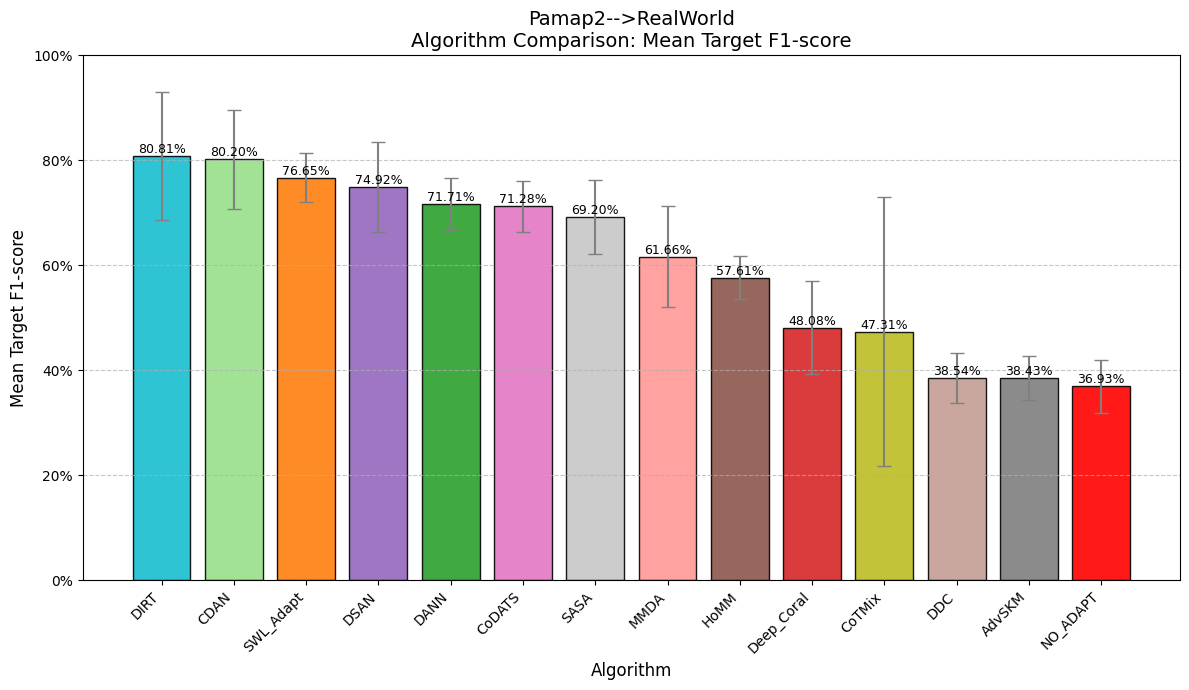

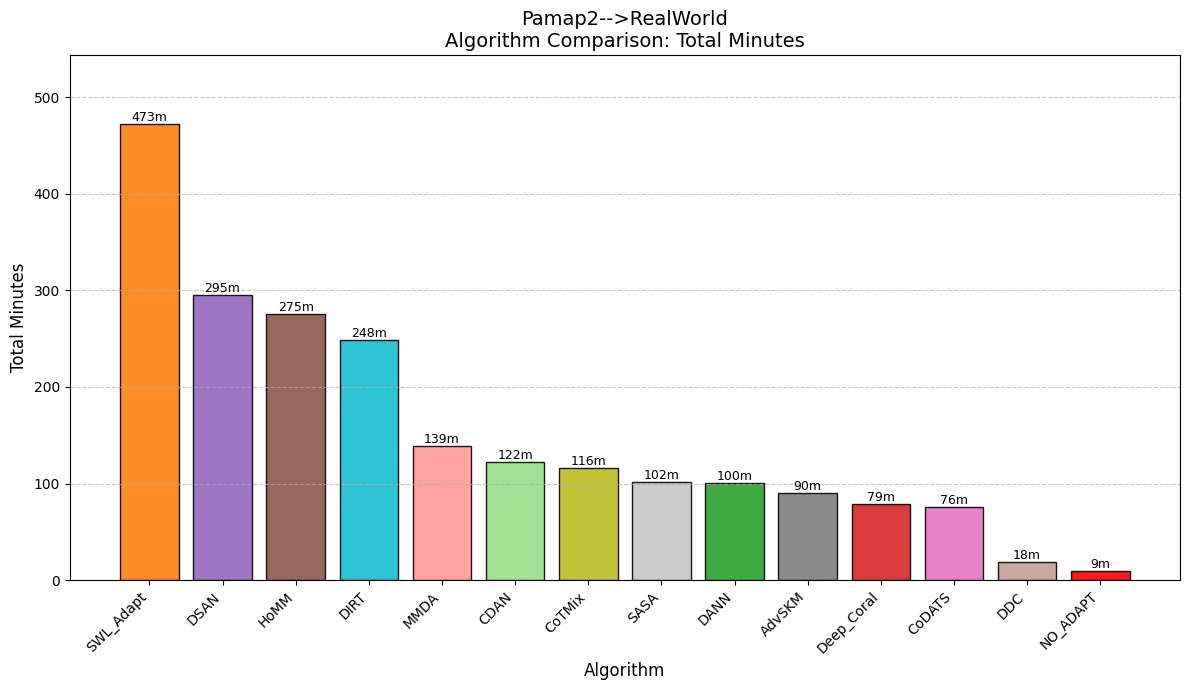

In [ ]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import os
import yaml
from datetime import datetime

# --- Configuration ---

# 1. SET THE *FILE PATH* TO YOUR MLRUNS FOLDER
MLRUNS_PATH = "../mlruns"

# 2. Set your Experiment ID
EXPERIMENT_ID = "256791731049137730" 

# 3. Set the Performance Metric
METRIC_TO_ANALYZE = "Target F1-score" 

# --- Persistent Color Map ---
try:
    tab20_colors = plt.cm.tab20.colors
except AttributeError: 
    tab20 = plt.get_cmap('tab20')
    tab20_colors = tab20.colors
    
ALGORITHM_COLOR_MAP = {
    'SWL_Adapt':    tab20_colors[2],
    'DANN':         tab20_colors[4],
    'Deep_Coral':   tab20_colors[6],
    'CDAN':         tab20_colors[5],
    'MMDA':         tab20_colors[7],
    'DSAN':         tab20_colors[8],
    'HoMM':         tab20_colors[10],
    'DDC':          tab20_colors[11],
    'CoDATS':       tab20_colors[12],
    'AdvSKM':       tab20_colors[14],
    'SASA':         tab20_colors[15],
    'CoTMix':       tab20_colors[16],
    'MCD':          tab20_colors[17],
    'DIRT':         tab20_colors[18],
    'NO_ADAPT':     '#FF0000', # Red
    'TARGET_ONLY':  '#00FF00', # Green
}
DEFAULT_COLOR = '#808080'
ALGORITHM_TO_EXCLUDE = 'uDAR'

# --- End Configuration ---

def extract_alg_name(run_name):
    """Extracts the algorithm name from the MLflow run name."""
    if not isinstance(run_name, str): return str(run_name)
    parts = run_name.split('_')
    # Assumes run name format is 'AlgorithmName_run_X'
    if len(parts) > 2 and parts[-2] == 'run':
        return '_'.join(parts[:-2])
    return run_name

def process_and_plot(df, experiment_name, target_col, is_percentage=True, use_sum=False):
    """
    Takes a dataframe, calculates stats (Mean or Sum), and generates a plot.
    """
    if df.empty:
        print("\n--- No runs left after filtering. Skipping plot. ---")
        return

    df = df.copy()
    
    # Apply algorithm name extraction and filtering
    df['algorithm'] = df["tags.mlflow.runName"].apply(extract_alg_name)
    df = df[df['algorithm'] != ALGORITHM_TO_EXCLUDE]
    
    # Filter for valid algorithms (at least 1 run)
    alg_counts = df['algorithm'].value_counts()
    valid_algs = alg_counts[alg_counts >= 1].index
    df = df[df['algorithm'].isin(valid_algs)]
    
    if df.empty:
        return

    # --- Calculation ---
    df = df.dropna(subset=[target_col])
    
    if use_sum:
        # For Time: Calculate Sum (Total)
        stats = df.groupby('algorithm')[target_col].agg(['sum', 'count'])
        stats = stats.rename(columns={'sum': 'value'})
        stats['std'] = 0 # No error bars for Sum
        title_prefix = "Total"
        print(f"\n--- Calculating Total Time (Sum) for {experiment_name} ---")
    else:
        # For Metrics: Calculate Mean
        stats = df.groupby('algorithm')[target_col].agg(['mean', 'std', 'count'])
        stats = stats.rename(columns={'mean': 'value'})
        stats['std'] = stats['std'].fillna(0)
        title_prefix = "Mean"
        print(f"\n--- Calculating Mean Performance for {experiment_name} ---")
    
    # Sort
    stats = stats.sort_values(by='value', ascending=False)
    
    # Print results table
    stats_print = stats.copy()
    if is_percentage:
        stats_print['value'] = (stats_print['value'] * 100).round(2)
        stats_print['std'] = (stats_print['std'] * 100).round(2)
    print(stats_print)

    # --- Plotting ---
    stats_for_plot = stats.reset_index()
    
    plt.figure(figsize=(12, 7))
    
    colors = [ALGORITHM_COLOR_MAP.get(alg, DEFAULT_COLOR) for alg in stats_for_plot['algorithm']]
    
    # Only show yerr if we are NOT using sum
    yerr = stats_for_plot['std'] if not use_sum else None
    
    bar_plot = plt.bar(
        stats_for_plot['algorithm'], 
        stats_for_plot['value'], 
        yerr=yerr, 
        capsize=5,
        color=colors,
        ecolor='gray',
        alpha=0.9,
        edgecolor='black'
    )
    
    # Dynamic Titles/Labels
    unit = METRIC_TO_ANALYZE if is_percentage else "Minutes"
    
    title = (
        f"{experiment_name}\n"
        f"Algorithm Comparison: {title_prefix} {unit}"
    )
    plt.title(title, fontsize=14)
    plt.xlabel('Algorithm', fontsize=12)
    plt.ylabel(f'{title_prefix} {unit}', fontsize=12)
    
    # Formatting Y-Axis
    if is_percentage:
        plt.ylim(0, 1.0) 
        plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    else:
        max_val = stats_for_plot['value'].max()
        plt.ylim(0, max_val * 1.15)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right') 

    # Add text labels on bars
    for bar in bar_plot:
        height = bar.get_height()
        if is_percentage:
            label = f"{height * 100:.2f}%"
        else:
            label = f"{height:.0f}m" 
            
        plt.text(
            bar.get_x() + bar.get_width() / 2.0, 
            height, 
            label,
            ha='center', va='bottom', color='black', fontsize=9
        )

    plt.tight_layout()
    
    # Save file
    clean_type = "total_time" if use_sum else "mean_metric"
    filename = f"plot_{clean_type}_all_runs.png"
    plt.savefig(filename)
    print(f"\n--- Plot saved to {filename} ---")
    
    return stats['value'].sum() if use_sum else None


def main():
    # --- Set MLflow to read from your local folder ---
    absolute_path = os.path.abspath(MLRUNS_PATH)
    tracking_uri = f"file:///{absolute_path.replace(os.sep, '/')}"
    
    try:
        mlflow.set_tracking_uri(tracking_uri) 
        runs = mlflow.search_runs(experiment_ids=[EXPERIMENT_ID])
    except Exception as e:
        print(f"Error reading MLflow: {e}")
        return

    # --- Read Experiment Name ---
    yaml_path = os.path.join(MLRUNS_PATH, EXPERIMENT_ID, "meta.yaml")
    experiment_name = f"Experiment {EXPERIMENT_ID}"
    try:
        with open(yaml_path, 'r') as f:
            meta_data = yaml.safe_load(f)
        experiment_name = meta_data.get('name', experiment_name)
        print(f"--- Processing Experiment: '{experiment_name}' ---")
    except:
        print(f"--- Processing Experiment ID: {EXPERIMENT_ID} ---")
        pass

    if len(runs) == 0:
        print("No runs found in this experiment.")
        return

    # --- Data Cleaning and Preparation ---
    metric_col = f"metrics.{METRIC_TO_ANALYZE}"
    run_name_col = "tags.mlflow.runName"
    
    if metric_col not in runs.columns:
        print(f"Error: Metric '{metric_col}' not found.")
        return

    cols_to_keep = [run_name_col, metric_col, 'start_time', 'end_time']
    df_all = runs[cols_to_keep].copy()
    df_all[metric_col] = pd.to_numeric(df_all[metric_col])

    # Calculate Duration in Minutes
    df_all['start_time'] = pd.to_datetime(df_all['start_time'])
    df_all['end_time'] = pd.to_datetime(df_all['end_time'])
    df_all['duration_minutes'] = (df_all['end_time'] - df_all['start_time']).dt.total_seconds() / 60.0
    
    # Filter out uDAR runs for accurate grand total calculation
    df_filtered = df_all.copy()
    df_filtered['algorithm'] = df_filtered[run_name_col].apply(extract_alg_name)
    df_filtered = df_filtered[df_filtered['algorithm'] != ALGORITHM_TO_EXCLUDE]

    print(f"Total runs found: {len(runs)}. Total runs used for plots (excluding {ALGORITHM_TO_EXCLUDE}): {len(df_filtered)}")

    # --- Generate Plots (2 Total) ---
    
    # 1. Performance Plot (Mean F1 Score) - use_sum=False
    process_and_plot(df_all, experiment_name, metric_col, is_percentage=True, use_sum=False)
    
    # 2. Time Plot (TOTAL Minutes) - use_sum=True
    total_minutes_sum = process_and_plot(df_all, experiment_name, "duration_minutes", is_percentage=False, use_sum=True)

    # --- PRINT GRAND TOTAL TIME STATISTICS ---
    if total_minutes_sum is not None:
        print("\n" + "="*45)
        print("      GRAND TOTAL TIME FOR ALL PLOTTED RUNS     ")
        print("="*45)
        print(f"Total Minutes (Excluding {ALGORITHM_TO_EXCLUDE}): {total_minutes_sum:.2f} min")
        print(f"Total Hours (Excluding {ALGORITHM_TO_EXCLUDE}):   {total_minutes_sum/60:.2f} hrs")
        print("="*45 + "\n")

if __name__ == "__main__":
    main()